<a href="https://colab.research.google.com/github/fezrestia/hello-world/blob/master/deep-learning/reinforcement-learning/DL4_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning from Zero 4 : Reinforcement Learning

## Total Setup

In [ ]:
#Setup Linux Env
!cd && git clone https://github.com/fezrestia/dot-config-files.git

!cp /root/dot-config-files/.vimrc /root/.vimrc
!cp /root/dot-config-files/.vimrc_local /root/.vimrc_local
!cp /root/dot-config-files/.vimrc_override /root/.vimrc_override
!echo "set notermguicolors" >> /root/.vimrc_override

!cp /root/dot-config-files/.zshrc /root/.zshrc

!cp /root/dot-config-files/.tmux.conf /root/.tmux.conf

!cp /root/dot-config-files/.gitconfig /root/.gitconfig
!touch /root/.gitconfig_local
!git config --file ~/.gitconfig_local user.name "Aki.SHIMO"
!git config --file ~/.gitconfig_local user.email "fezrestia@gmail.com"

!cd && git clone https://github.com/fezrestia/hello-world.git
!mkdir /root/.deepzero/

!apt-get install -y zsh vim tmux

!pip install mypy
!pip install cupy-cuda12

!tmux kill-server

!vim -es -u ~/.vimrc +PlugInstall\ --sync +qall



# gymnasium display
!apt-get install -y xvfb
!pip install pyvirtualdisplay
!pip install gymnasium
import base64
import io
import gymnasium as gym
from gym.wrappers import RecordVideo
from IPython import display
from pyvirtualdisplay import Display
import glob



# Setup Python Env
import numpy as np
np.random.seed(0)


# Sync samples
!cd && git clone https://github.com/oreilly-japan/deep-learning-from-scratch-3.git
!cd && git clone https://github.com/oreilly-japan/deep-learning-from-scratch-4.git



Cloning into 'dot-config-files'...
remote: Enumerating objects: 660, done.
remote: Counting objects: 100% (238/238), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 660 (delta 129), reused 209 (delta 105), pack-reused 422 (from 1)
Receiving objects: 100% (660/660), 96.92 KiB | 9.69 MiB/s, done.
Resolving deltas: 100% (335/335), done.
Cloning into 'hello-world'...
remote: Enumerating objects: 2882, done.
remote: Counting objects: 100% (533/533), done.
remote: Compressing objects: 100% (223/223), done.
remote: Total 2882 (delta 392), reused 433 (delta 302), pack-reused 2349 (from 2)
Receiving objects: 100% (2882/2882), 56.54 MiB | 16.91 MiB/s, done.
Resolving deltas: 100% (1303/1303), done.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tmux is already the newest version (3.2a-4ubuntu0.2).
vim is already the newest version (2:8.2.3995-1ubuntu2.30).
The following additional packages will be installed:
  zsh-common
Su

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Cloning into 'deep-learning-from-scratch-3'...
remote: Enumerating objects: 1981, done.
remote: Counting objects: 100% (460/460), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 1981 (delta 417), reused 399 (delta 399), pack-reused 1521 (from 2)
Receiving objects: 100% (1981/1981), 14.55 MiB | 18.30 MiB/s, done.
Resolving deltas: 100% (1388/1388), done.
Cloning into 'deep-learning-from-scratch-4'...
remote: Enumerating objects: 415, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 415 (delta 159), reused 131 (delta 131), pack-reused 220 (from 1)
Receiving objects: 100% (415/415), 1.02 MiB | 15.90 MiB/s, done.
Resolving deltas: 100% (239/239), done.


In [ ]:
# bandit problem

rewards: list[float] = []

for n in range(1, 11):  # 1 - 10
    reward: float = np.random.rand()
    rewards.append(reward)

    Q: float = sum(rewards) / n
    print(Q)


0.5488135039273248
0.6320014351498722
0.6222554154571294
0.6029123573420713
0.567060845741438
0.5801997236289743
0.5598265075766483
0.6013198192273272
0.6415801460355164
0.6157662833145425


In [ ]:
Q: float = 0.0

for n in range(1, 11):
    reward: float = np.random.rand()
    Q += (reward - Q) / n
    print(Q)


0.31856895245132366
0.4929896662075027
0.3725923982731325
0.45852609973449077
0.4247020983770328
0.3844503089820468
0.413316398386052
0.3641652918612322
0.41580692934524677
0.3746957840299768


In [ ]:
class Bandit:
    def __init__(self, arms: int = 10) -> None:
        self.rates: list[float] = np.random.rand(arms)

    def play(self, arm: int) -> int:
        rate: float = self.rates[arm]
        if rate > np.random.rand():
            return 1
        else:
            return 0


class Agent:
    def __init__(self, epsilon: float, action_size: int = 10) -> None:
        self.epsilon: float = epsilon
        self.Qs: np.ndarray = np.zeros(action_size)
        self.ns: np.ndarray = np.zeros(action_size)

    def update(self, action: int, reward: float) -> None:
        self.ns[action] += 1
        self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

    def get_action(self) -> int:
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, len(self.Qs))
        return np.argmax(self.Qs)



# RUN
if __name__ == "__main__":
    print("# RUN")

    bandit: Bandit = Bandit()
    Qs: np.ndarray = np.zeros(10)
    ns: np.ndarray = np.zeros(10)

    for n in range(10):
        action: int = np.random.randint(0, 10)
        reward: float = bandit.play(action)

        ns[action] += 1
        Qs[action] += (reward - Qs[action]) / ns[action]
        print(Qs)


# RUN
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[1. 0. 0. 0. 1. 0. 0. 1. 0. 0.]
[1. 0. 0. 0. 1. 0. 0. 1. 0. 0.]
[1. 0. 0. 0. 1. 0. 0. 1. 0. 0.]
[1. 0. 0. 0. 1. 0. 0. 1. 0. 0.]
[1. 0. 0. 0. 1. 0. 1. 1. 0. 0.]
[1. 0. 0. 0. 1. 0. 1. 1. 0. 0.]


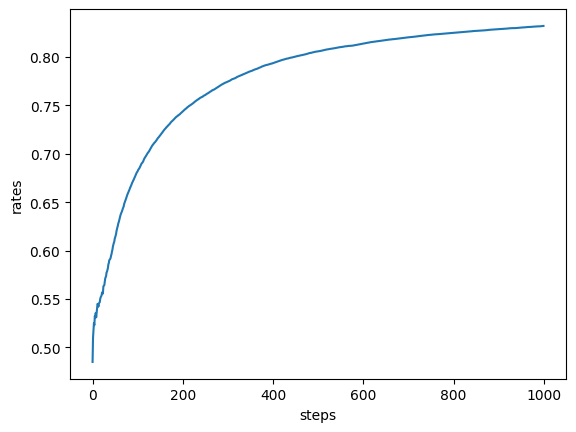

<Figure size 640x480 with 0 Axes>

In [ ]:
# normal bandit

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


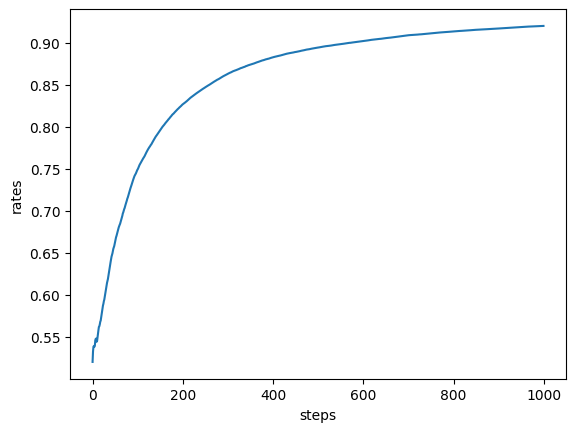

<Figure size 640x480 with 0 Axes>

In [ ]:
# non stat bandit

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


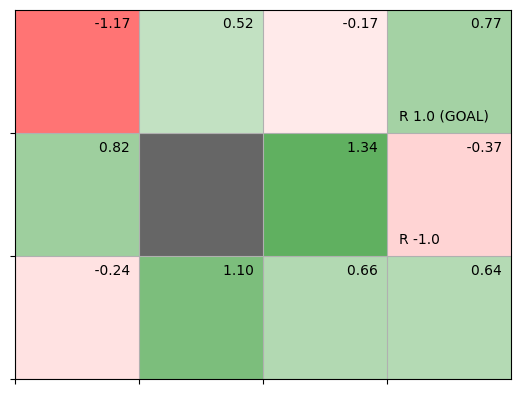

<Figure size 640x480 with 0 Axes>

In [ ]:
# GridWorld

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


{0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}


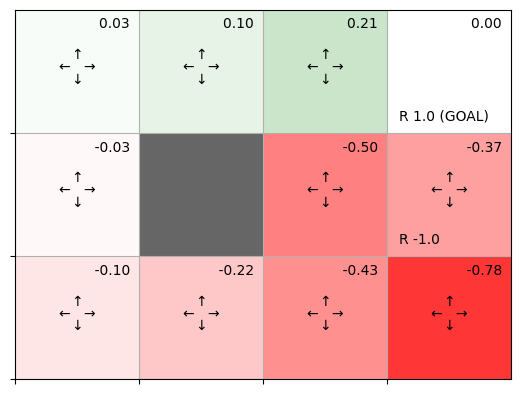

<Figure size 640x480 with 0 Axes>

In [ ]:
# GridWorld

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


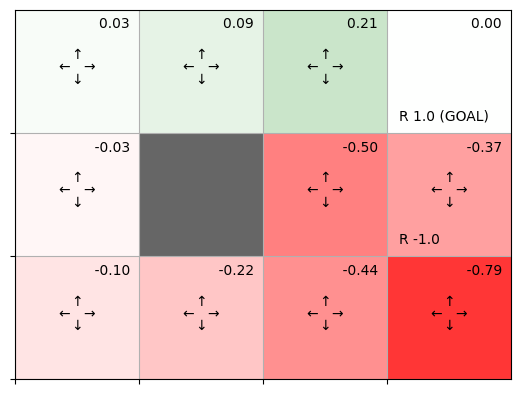

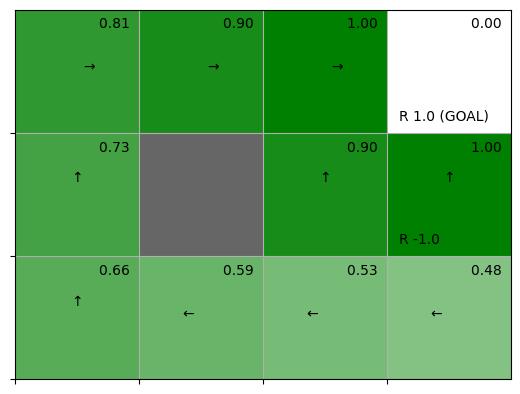

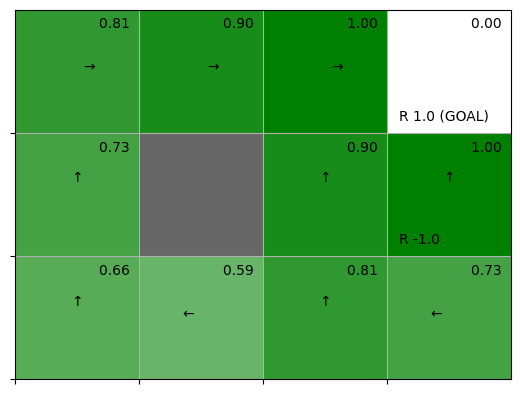

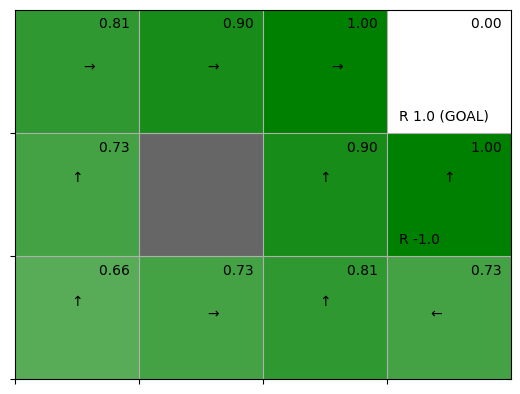

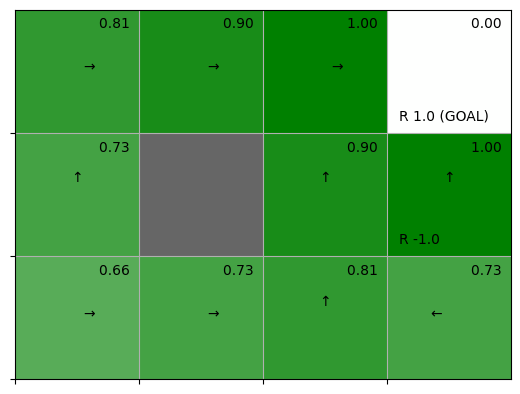

<Figure size 640x480 with 0 Axes>

In [ ]:
# greedy policy : policy iter

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


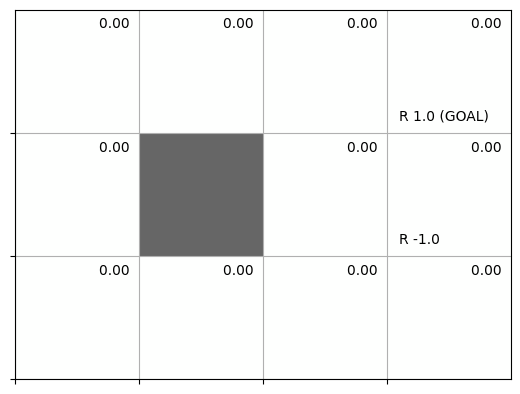

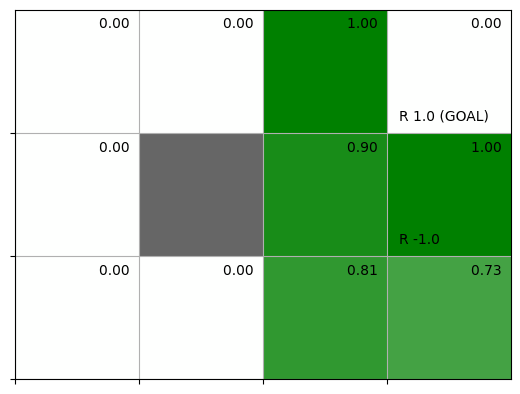

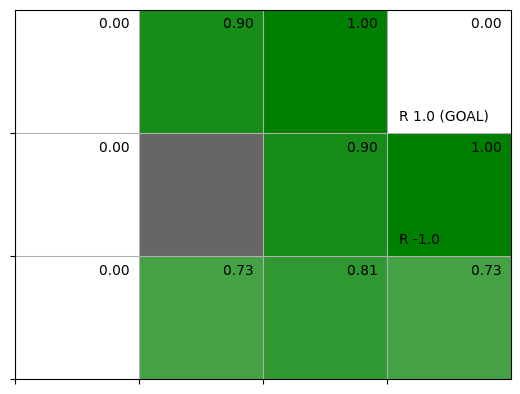

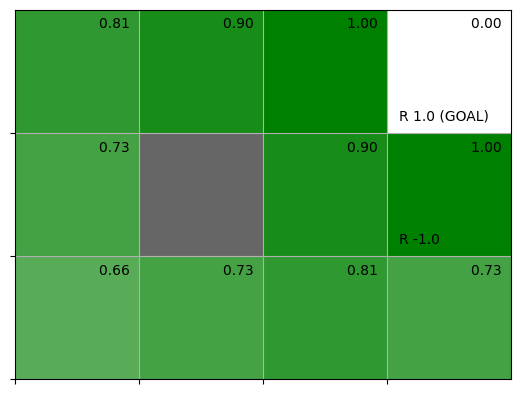

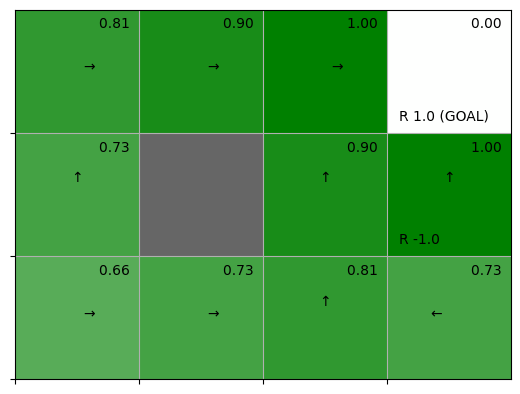

<Figure size 640x480 with 0 Axes>

In [ ]:
# greedy policy : value iter

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


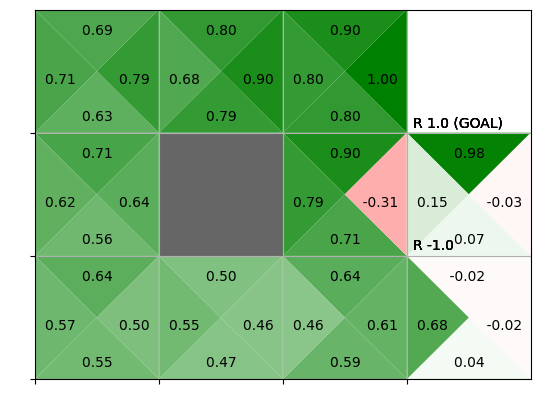

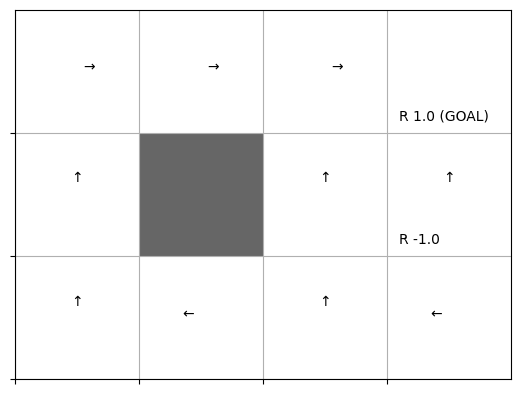

<Figure size 640x480 with 0 Axes>

In [ ]:
# monte carlo

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


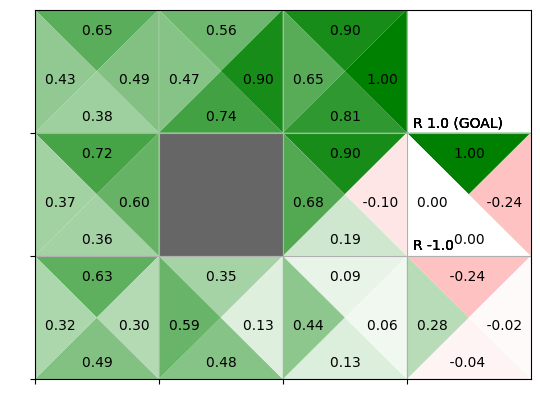

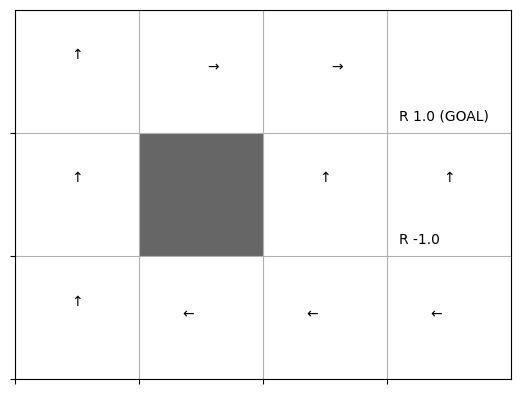

<Figure size 640x480 with 0 Axes>

In [ ]:
# temporal difference

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


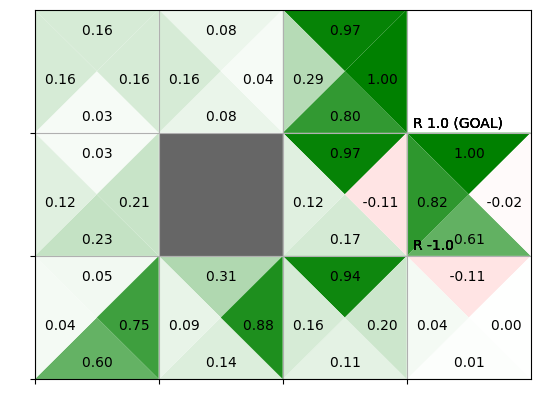

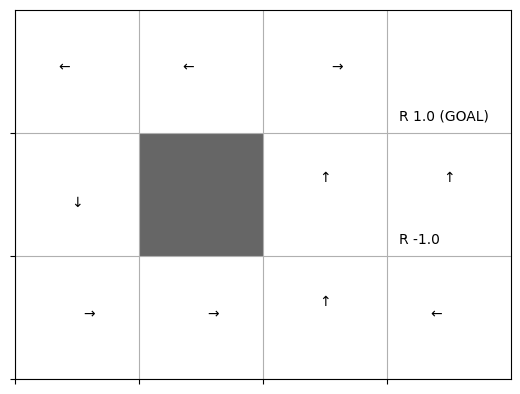

<Figure size 640x480 with 0 Axes>

In [ ]:
# Sarsa Off Policy

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


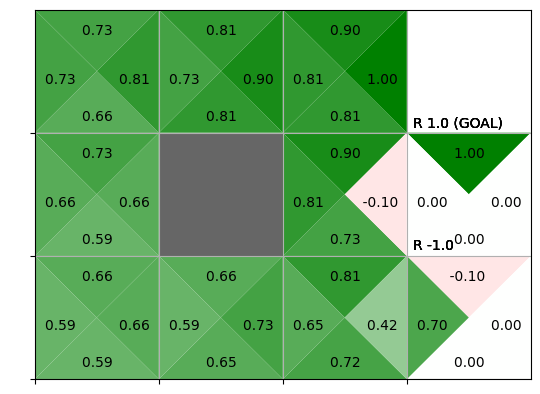

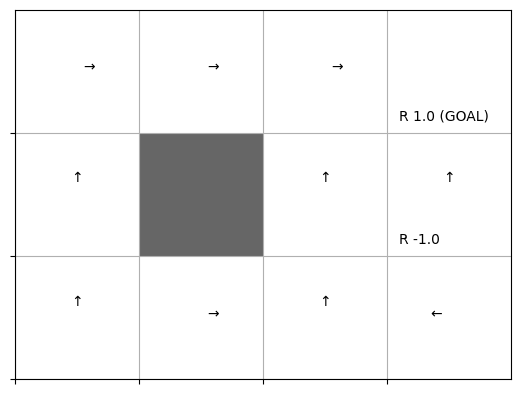

<Figure size 640x480 with 0 Axes>

In [ ]:
# Q-Learning

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


average_loss = 0.010452992884944865
average_loss = 4.124771812596598e-05
average_loss = 0.002607306630961294
average_loss = 0.00025492072130605113
average_loss = 2.5674154520689653e-06
average_loss = 8.355191629673003e-06
average_loss = 9.739233252842826e-07
average_loss = 0.0005119043278830936
average_loss = 5.488939451154065e-09
average_loss = 7.793591506978265e-08


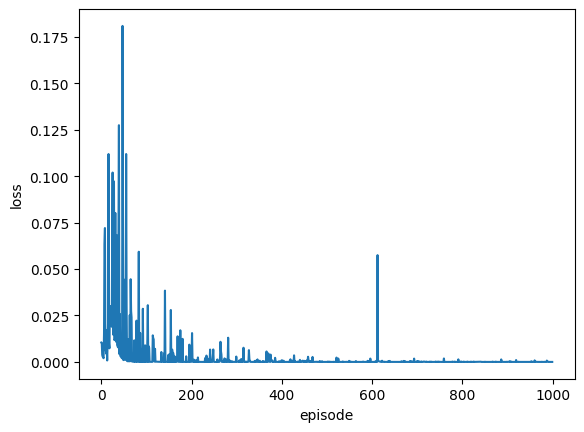

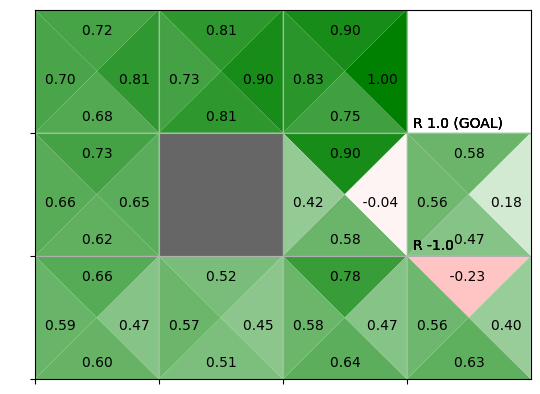

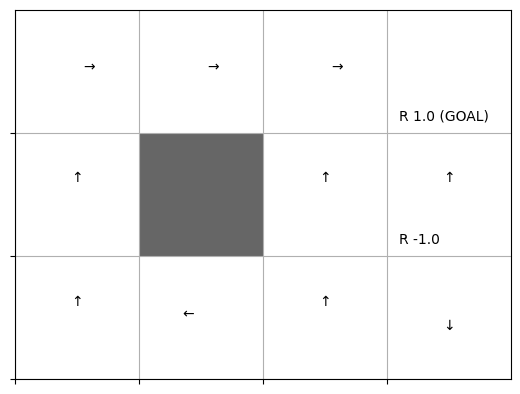

<Figure size 640x480 with 0 Axes>

In [ ]:
# DNN Q-Learning

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


In [ ]:
# Test gymnasium cart pole

import base64
import io
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython import display
from pyvirtualdisplay import Display
import glob

d = Display()
d.start()

video_dir = "./videos"
env = RecordVideo(gym.make("CartPole-v1", render_mode = "rgb_array"), video_dir)

state, info = env.reset()
print(f"state = {state}")

done: bool = False
while not done:
    #action = env.action_space.sample()
    action = np.random.choice([0, 1])

    next_state, reward, terminated, truncated, info = env.step(action)

    print(f"state = {next_state}")

    if terminated or truncated:
        #observation, info = env.reset()
        done = True

env.close()


mp4_files = glob.glob(f"{video_dir}/*.mp4")
for mp4_file in mp4_files:
    video = io.open(mp4_file, 'r+b').read()
    encoded = base64.b64encode(video)

    display.display(display.HTML(data = """
            <video alt="test" controls>
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
            </video>
            """.format(encoded.decode("ascii"))))


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


state = [-0.01058099  0.00991431 -0.0212351  -0.04917113]
state = [-0.0103827   0.20533422 -0.02221852 -0.34847754]
state = [-0.00627602  0.01053521 -0.02918807 -0.06288287]
state = [-0.00606531  0.20606323 -0.03044573 -0.36463004]
state = [-0.00194405  0.01138689 -0.03773833 -0.08170054]
state = [-0.00171631  0.20702893 -0.03937234 -0.3860471 ]
state = [ 0.00242427  0.01248738 -0.04709328 -0.10603339]
state = [ 0.00267401 -0.18192917 -0.04921395  0.1714278 ]
state = [-0.00096457 -0.37631345 -0.0457854   0.44818813]
state = [-0.00849084 -0.18057476 -0.03682163  0.14143158]
state = [-0.01210233  0.01505467 -0.033993   -0.16263677]
state = [-0.01180124  0.21064635 -0.03724574 -0.4658468 ]
state = [-0.00758831  0.40627423 -0.04656267 -0.7700328 ]
state = [ 0.00053717  0.21182299 -0.06196333 -0.4923566 ]
state = [ 0.00477363  0.01762726 -0.07181046 -0.21982758]
state = [ 0.00512618  0.2136983  -0.07620701 -0.5342703 ]
state = [ 0.00940014  0.01972611 -0.08689242 -0.26653963]
state = [ 0.00

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


total_reward = 10.0
total_reward = 10.0
total_reward = 10.0
total_reward = 8.0
total_reward = 9.0
total_reward = 11.0
total_reward = 8.0
total_reward = 10.0
total_reward = 9.0
total_reward = 29.0
total_reward = 9.0
total_reward = 92.0
total_reward = 151.0
total_reward = 173.0
total_reward = 189.0
total_reward = 157.0
total_reward = 253.0
total_reward = 152.0
total_reward = 123.0
total_reward = 170.0
total_reward = 162.0
total_reward = 131.0
total_reward = 150.0
total_reward = 137.0
total_reward = 134.0
total_reward = 100.0
total_reward = 113.0
total_reward = 116.0
total_reward = 91.0
total_reward = 127.0


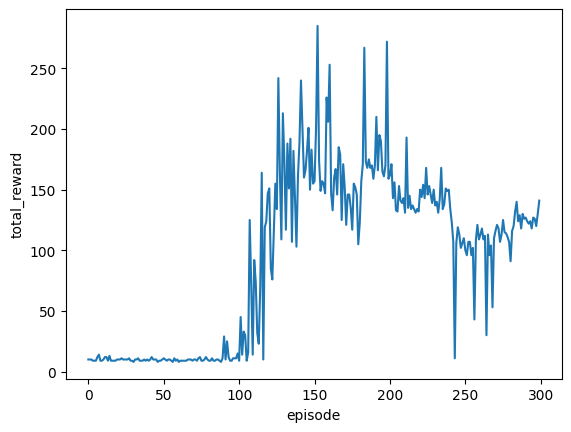

<Figure size 640x480 with 0 Axes>

In [ ]:
# DQN Agent

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


total_reward = 21.0
total_reward = 14.0
total_reward = 16.0
total_reward = 32.0
total_reward = 21.0
total_reward = 24.0
total_reward = 33.0
total_reward = 33.0
total_reward = 28.0
total_reward = 16.0
total_reward = 38.0
total_reward = 24.0
total_reward = 21.0
total_reward = 154.0
total_reward = 44.0
total_reward = 54.0
total_reward = 24.0
total_reward = 48.0
total_reward = 51.0
total_reward = 39.0
total_reward = 96.0
total_reward = 35.0
total_reward = 80.0
total_reward = 111.0
total_reward = 54.0
total_reward = 40.0
total_reward = 82.0
total_reward = 78.0
total_reward = 53.0
total_reward = 93.0


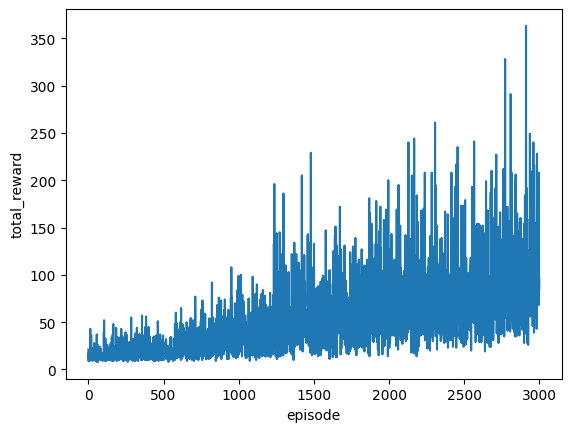

<Figure size 640x480 with 0 Axes>

In [ ]:
# Policy Gradient Agent

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


total_reward = 18.0
total_reward = 18.0
total_reward = 63.0
total_reward = 42.0
total_reward = 46.0
total_reward = 185.0
total_reward = 125.0
total_reward = 137.0
total_reward = 148.0
total_reward = 430.0
total_reward = 497.0
total_reward = 500.0
total_reward = 321.0
total_reward = 236.0
total_reward = 500.0
total_reward = 290.0
total_reward = 193.0
total_reward = 201.0
total_reward = 348.0
total_reward = 270.0
total_reward = 476.0
total_reward = 500.0
total_reward = 268.0
total_reward = 375.0
total_reward = 500.0
total_reward = 269.0
total_reward = 467.0
total_reward = 294.0
total_reward = 235.0
total_reward = 475.0


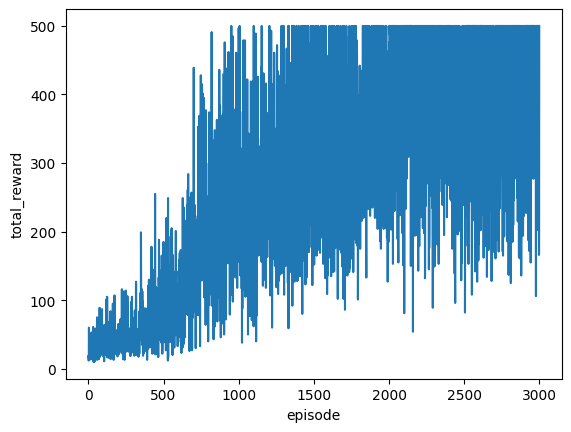

<Figure size 640x480 with 0 Axes>

In [ ]:

# REINFORCE

%run /root/hello-world/deep-learning/reinforcement-learning/main.py


total_reward = 10.0
total_reward = 11.0
total_reward = 11.0
total_reward = 12.0
total_reward = 63.0
total_reward = 143.0
total_reward = 228.0
total_reward = 160.0
total_reward = 316.0
total_reward = 166.0
total_reward = 500.0
total_reward = 187.0
total_reward = 362.0
total_reward = 286.0
total_reward = 272.0
total_reward = 325.0
total_reward = 352.0
total_reward = 213.0
total_reward = 233.0
total_reward = 286.0
total_reward = 149.0
total_reward = 214.0
total_reward = 295.0
total_reward = 229.0
total_reward = 221.0
total_reward = 335.0
total_reward = 360.0
total_reward = 478.0
total_reward = 261.0
total_reward = 155.0


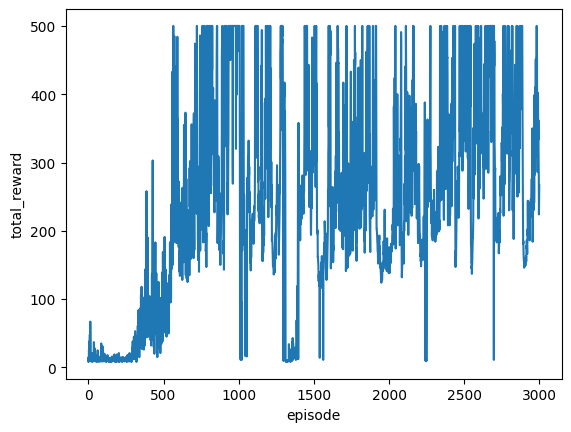

<Figure size 640x480 with 0 Axes>

In [ ]:

# Actor-Critic Agent

%run /root/hello-world/deep-learning/reinforcement-learning/main.py
